# Phase 3 Step 5 — Calibration and Operational Policy

ET-2 is frozen. This notebook compares no calibration, August-only sigmoid calibration, and August-only isotonic calibration, then freezes a development-only operating policy. Positive class 1 means no basket in `(T,T+28d]`, not churn. **November lockbox outcomes remain untouched.**

## Frozen model and why calibration matters

ET-2 is a ranking winner, but raw tree-ensemble scores need not equal observed event rates. Calibration is accepted only if August-fitted mapping materially improves September/October Brier and log loss without damaging ranking or temporal stability. Probability language is conditional on that evidence.

In [1]:
from pathlib import Path
import sys
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks':ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'src'))
import numpy as np,pandas as pd,pyreadr,matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score,roc_auc_score
from marketmind.return_risk.calibration import ScoreCalibrator,CALIBRATION_SNAPSHOT
from marketmind.return_risk.cohorts import build_labeled_cohort
from marketmind.return_risk.evaluation import score_metrics,calibration_bins,expected_calibration_error
from marketmind.return_risk.features import build_candidate_features,baseline_features,BASELINE_FEATURE_ORDER
from marketmind.return_risk.models import TRAINING_SNAPSHOTS,VALIDATION_SNAPSHOTS,LOCKBOX_SNAPSHOT,fit_extra_trees_candidate
from marketmind.return_risk.policy import top_capacity_flags,threshold_summary,point_in_time_segment_join
from marketmind.segmentation.bundle import load_bundle
from marketmind.segmentation.assignment import assign_from_transactions
pd.set_option('display.max_columns',40)
RAW=ROOT/'data'/'raw'/'complete_journey';ART=ROOT/'reports'/'return_risk'/'artifacts';FIG=ROOT/'reports'/'return_risk'/'figures';ART.mkdir(parents=True,exist_ok=True);FIG.mkdir(parents=True,exist_ok=True)
BASE_TRAIN=TRAINING_SNAPSHOTS[:4];ASSESSMENT=VALIDATION_SNAPSHOTS
assert CALIBRATION_SNAPSHOT==TRAINING_SNAPSHOTS[4] and LOCKBOX_SNAPSHOT not in (*BASE_TRAIN,CALIBRATION_SNAPSHOT,*ASSESSMENT)

## Calibration protocol

Base ET-2 is fit on April–July only. August is used once to fit sigmoid and isotonic mappings. September and October remain assessment-only. This acknowledges that they were previously used for family selection and prevents further fitting to their labels.

In [2]:
transactions=pyreadr.read_r(str(RAW/'transactions.rds'))[None];products=pyreadr.read_r(str(RAW/'products.rda'))['products'];transactions.transaction_timestamp=pd.to_datetime(transactions.transaction_timestamp)
frames=[]
for snapshot in (*BASE_TRAIN,CALIBRATION_SNAPSHOT,*ASSESSMENT):
    X=baseline_features(build_candidate_features(transactions,products,snapshot));y=build_labeled_cohort(transactions,snapshot,28,'2017-12-31 23:59:59')[['return_risk_target']]
    z=X.join(y,validate='one_to_one').reset_index();z['snapshot_at']=snapshot;frames.append(z)
data=pd.concat(frames,ignore_index=True);base_train=data[data.snapshot_at.isin(BASE_TRAIN)].copy();calibration=data[data.snapshot_at.eq(CALIBRATION_SNAPSHOT)].copy();assessment=data[data.snapshot_at.isin(ASSESSMENT)].copy()
assert len(base_train)==8004 and len(calibration)==2219 and len(assessment)==4529 and data.snapshot_at.max()==ASSESSMENT[-1]
X_base=base_train.loc[:,BASELINE_FEATURE_ORDER];y_base=base_train.return_risk_target;X_cal=calibration.loc[:,BASELINE_FEATURE_ORDER];y_cal=calibration.return_risk_target;X_assess=assessment.loc[:,BASELINE_FEATURE_ORDER];y_assess=assessment.return_risk_target
base_model=fit_extra_trees_candidate('ET-2',X_base,y_base,base_train.snapshot_at);cal_raw=base_model.predict_proba(X_cal)[:,1];assessment_raw=base_model.predict_proba(X_assess)[:,1]
calibrators={name:ScoreCalibrator(name).fit(cal_raw,y_cal,calibration.snapshot_at) for name in ('sigmoid','isotonic')};scores={'uncalibrated':assessment_raw,**{name:c.transform(assessment_raw) for name,c in calibrators.items()}}

## Candidate calibration results and temporal validation

In [3]:
rows=[]
for name,score in scores.items():
    for cohort,date in [('September','2017-09-30'),('October','2017-10-31'),('Pooled',None)]:
        mask=np.ones(len(assessment),bool) if date is None else assessment.snapshot_at.dt.date==pd.Timestamp(date).date();m=score_metrics(y_assess[mask],score[mask]);rows.append({'calibration':name,'cohort':cohort,**m,'ece_10':expected_calibration_error(y_assess[mask],score[mask],10)})
metrics=pd.DataFrame(rows);metrics.to_csv(ART/'calibration_candidate_metrics.csv',index=False);display(metrics.drop(columns=['confusion_matrix','precision_at_0_5','recall_at_0_5','f1_at_0_5']).round(5))

,calibration,cohort,n,prevalence,pr_auc,roc_auc,log_loss,brier,ece_10
0,uncalibrated,September,2247,0.13796,0.50101,0.86437,0.29318,0.09168,0.03205
1,uncalibrated,October,2282,0.13804,0.47128,0.85016,0.30225,0.09439,0.02737
2,uncalibrated,Pooled,4529,0.13800,0.48495,0.85720,0.29775,0.09304,0.02871
3,sigmoid,September,2247,0.13796,0.50101,0.86437,0.29949,0.09031,0.04327
4,sigmoid,October,2282,0.13804,0.47128,0.85016,0.30940,0.09349,0.03650
5,sigmoid,Pooled,4529,0.13800,0.48495,0.85720,0.30448,0.09191,0.03845
6,isotonic,September,2247,0.13796,0.47372,0.86287,0.35288,0.08917,0.01047
7,isotonic,October,2282,0.13804,0.44141,0.84760,0.33846,0.09261,0.01492
8,isotonic,Pooled,4529,0.13800,0.45677,0.85517,0.34562,0.09090,0.01189


## Calibration curves and observed risk by score bin

Quantile bins show score level versus observed no-return prevalence. No mapping is fitted on September or October.

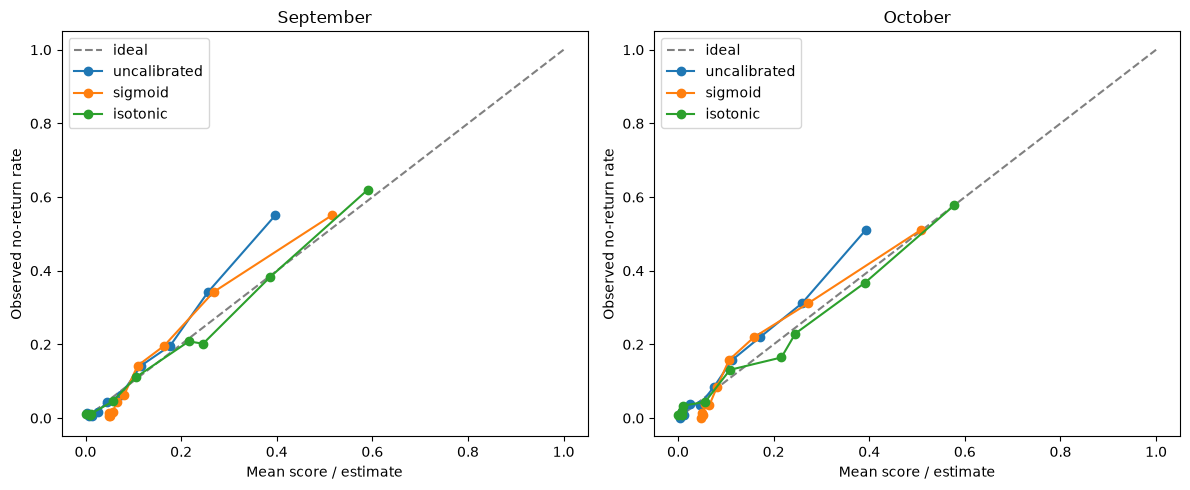

,mean_score,observed_rate,calibration,cohort
0,0.0037,0.0133,uncalibrated,September
1,0.0070,0.0044,uncalibrated,September
2,0.0139,0.0045,uncalibrated,September
3,0.0262,0.0178,uncalibrated,September
4,0.0453,0.0444,uncalibrated,September
5,0.0735,0.0625,uncalibrated,September
6,0.1160,0.1422,uncalibrated,September
7,0.1771,0.1964,uncalibrated,September
8,0.2563,0.3422,uncalibrated,September
9,0.3974,0.5511,uncalibrated,September


In [4]:
bins=[];fig,axes=plt.subplots(1,2,figsize=(12,5))
for ax,(cohort,date) in zip(axes,[('September','2017-09-30'),('October','2017-10-31')]):
    mask=assessment.snapshot_at.dt.date==pd.Timestamp(date).date();ax.plot([0,1],[0,1],'--',color='grey',label='ideal')
    for name,score in scores.items():
        b=calibration_bins(y_assess[mask],score[mask],10).assign(calibration=name,cohort=cohort);bins.append(b);ax.plot(b.mean_score,b.observed_rate,marker='o',label=name)
    ax.set(title=cohort,xlabel='Mean score / estimate',ylabel='Observed no-return rate');ax.legend()
fig.tight_layout();fig.savefig(FIG/'calibration_candidates_by_month.png',dpi=160);plt.show();bins=pd.concat(bins,ignore_index=True);bins.to_csv(ART/'calibration_candidate_bins.csv',index=False);display(bins.round(4))

## Calibration selection

Apply the frozen rule: calibration must materially improve Brier/log loss, preserve ranking, and remain reasonably stable in both months. Sigmoid is strictly monotonic; isotonic may create ties and overfit the single August cohort.

In [5]:
pooled=metrics[metrics.cohort.eq('Pooled')].set_index('calibration');display(pooled[['pr_auc','roc_auc','brier','log_loss','ece_10']].round(5))
# Decision is evidence based but not an optimization loop.
selected='sigmoid' if (pooled.loc['sigmoid','brier']<pooled.loc['uncalibrated','brier'] and pooled.loc['sigmoid','log_loss']<pooled.loc['uncalibrated','log_loss']) else 'uncalibrated'
selected_score=scores[selected];selected

,pr_auc,roc_auc,brier,log_loss,ece_10
calibration,,,,,
uncalibrated,0.48495,0.85720,0.09304,0.29775,0.02871
sigmoid,0.48495,0.85720,0.09191,0.30448,0.03845
isotonic,0.45677,0.85517,0.09090,0.34562,0.01189


'uncalibrated'

## Threshold analysis

The deterministic grid is descriptive and uses pooled September/October only. Accuracy is not a selection metric and no score threshold is frozen unless the final policy explicitly requires one.

In [6]:
grid=np.arange(.05,.51,.05);thresholds=threshold_summary(y_assess,selected_score,grid);thresholds.to_csv(ART/'calibrated_threshold_grid.csv',index=False);display(thresholds.round(4))

,threshold,flagged,positive_prediction_rate,precision,recall,f1,tn,fp,fn,tp
0,0.05,2399,0.5297,0.2464,0.9456,0.3909,2096,1808,34,591
1,0.10,1723,0.3804,0.3157,0.8704,0.4634,2725,1179,81,544
2,0.15,1295,0.2859,0.3645,0.7552,0.4917,3081,823,153,472
3,0.20,972,0.2146,0.4167,0.6480,0.5072,3337,567,220,405
4,0.25,704,0.1554,0.4716,0.5312,0.4996,3532,372,293,332
5,0.30,501,0.1106,0.5170,0.4144,0.4600,3662,242,366,259
6,0.35,302,0.0667,0.5828,0.2816,0.3797,3778,126,449,176
7,0.40,184,0.0406,0.6141,0.1808,0.2794,3833,71,512,113
8,0.45,96,0.0212,0.6979,0.1072,0.1859,3875,29,558,67
9,0.50,43,0.0095,0.6744,0.0464,0.0868,3890,14,596,29


## Capacity policy

Capacity ranking has predictable workload even when prevalence or calibration drifts. Report 5/10/15/20% pooled and month-level stability. Lift is precision divided by cohort prevalence.

In [7]:
capacity_rows=[]
stable_keys=(assessment.household_id.astype(str)+'|'+assessment.snapshot_at.astype(str)).to_numpy()
for cohort,date in [('September','2017-09-30'),('October','2017-10-31'),('Pooled',None)]:
    mask=np.ones(len(assessment),bool) if date is None else assessment.snapshot_at.dt.date==pd.Timestamp(date).date();y=y_assess.to_numpy()[mask];s=selected_score[mask];keys=stable_keys[mask]
    for cap in (.05,.10,.15,.20):
        flags=top_capacity_flags(s,cap,keys);tp=int(y[flags].sum());precision=tp/flags.sum();capacity_rows.append({'cohort':cohort,'capacity':cap,'flagged':int(flags.sum()),'positives_captured':tp,'precision':precision,'recall':tp/y.sum(),'base_prevalence':y.mean(),'lift':precision/y.mean()})
capacity=pd.DataFrame(capacity_rows);capacity.to_csv(ART/'calibrated_capacity_metrics.csv',index=False);display(capacity.round(4))

,cohort,capacity,flagged,positives_captured,precision,recall,base_prevalence,lift
0,September,0.05,113,69,0.6106,0.2226,0.138,4.4260
1,September,0.10,225,124,0.5511,0.4000,0.138,3.9947
2,September,0.15,338,164,0.4852,0.5290,0.138,3.5170
3,September,0.20,450,201,0.4467,0.6484,0.138,3.2376
4,October,0.05,115,69,0.6000,0.2190,0.138,4.3467
5,October,0.10,229,117,0.5109,0.3714,0.138,3.7013
6,October,0.15,343,159,0.4636,0.5048,0.138,3.3582
7,October,0.20,457,188,0.4114,0.5968,0.138,2.9802
8,Pooled,0.05,227,137,0.6035,0.2192,0.138,4.3734
9,Pooled,0.10,453,240,0.5298,0.3840,0.138,3.8392


## Business policy scenarios

- **Conservative outreach:** top 5%; smallest workload and highest precision.
- **Balanced monitoring:** top 10%; moderate workload with useful precision/recall and stable monthly issuance.
- **Broad retention campaign:** top 20%; greater recall with lower precision.

The primary recommendation is capacity ranking because ET-2 score calibration can drift and fixed-threshold volume is unstable. The displayed calibrated estimate remains secondary context.

## Segmentation post-hoc analysis

The frozen September segmentation artifact is applied using behavior available at each validation snapshot: September at September month-end and October forward using the already-frozen artifact. Segment is never passed to ET-2. The join requires identical household/snapshot keys.

In [8]:
bundle=load_bundle(ROOT/'models'/'segmentation'/'model.joblib');assignment_frames=[]
for snapshot in ASSESSMENT:
    a=assign_from_transactions(bundle,transactions,products,snapshot_date=snapshot);assignment_frames.append(a[a.eligibility_status.eq('eligible')])
assignments=pd.concat(assignment_frames,ignore_index=True)
score_frame=assessment[['household_id','snapshot_at','return_risk_target']].copy();score_frame['score']=selected_score
joined=point_in_time_segment_join(score_frame,assignments);flags=top_capacity_flags(joined.score,.10,joined.household_id.astype(str)+'|'+joined.snapshot_at.astype(str));joined['top_10_flag']=flags
segment_rows=[]
for segment,g in joined.groupby('segment_code'):
    segment_rows.append({'segment_code':segment,'n':len(g),'positives':int(g.return_risk_target.sum()),'prevalence':g.return_risk_target.mean(),'pr_auc':average_precision_score(g.return_risk_target,g.score) if g.return_risk_target.nunique()==2 else np.nan,'roc_auc':roc_auc_score(g.return_risk_target,g.score) if g.return_risk_target.nunique()==2 else np.nan,'mean_score':g.score.mean(),'median_score':g.score.median(),'top10_flagged':int(g.top_10_flag.sum()),'within_segment_flag_rate':g.top_10_flag.mean(),'share_of_all_flags':g.top_10_flag.sum()/joined.top_10_flag.sum()})
segments=pd.DataFrame(segment_rows);segments.to_csv(ART/'segment_posthoc_metrics.csv',index=False);display(segments.round(4))

,segment_code,n,positives,prevalence,pr_auc,roc_auc,mean_score,median_score,top10_flagged,within_segment_flag_rate,share_of_all_flags
0,HIGH_ENGAGEMENT_BROAD,2228,92,0.0413,0.2058,0.8127,0.0357,0.0166,6,0.0027,0.0132
1,LOWER_ENGAGEMENT_FOCUSED,1724,473,0.2744,0.5306,0.7583,0.2147,0.1949,410,0.2378,0.9051
2,PROMOTION_BASKET_BUILDERS,577,60,0.1040,0.4251,0.8627,0.0935,0.0460,37,0.0641,0.0817


## Coverage analysis

Segment score/flag differences are descriptive operational coverage checks, not protected-attribute fairness claims or causal evidence.

In [9]:
coverage=joined.groupby(['snapshot_at','segment_code']).agg(n=('household_id','size'),prevalence=('return_risk_target','mean'),mean_score=('score','mean'),median_score=('score','median'),flag_rate=('top_10_flag','mean'),flags=('top_10_flag','sum')).reset_index();coverage.to_csv(ART/'segment_coverage_by_month.csv',index=False);display(coverage.round(4))

/var/folders/qr/5t89y2n92z12ddb73k2_ybdm0000gn/T/ipykernel_77728/2660822432.py:1: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  coverage=joined.groupby(['snapshot_at','segment_code']).agg(n=('household_id','size'),prevalence=('return_risk_target','mean'),mean_score=('score','mean'),median_score=('score','median'),flag_rate=('top_10_flag','mean'),flags=('top_10_flag','sum')).reset_index();coverage.to_csv(ART/'segment_coverage_by_month.csv',index=False);display(coverage.round(4))


,snapshot_at,segment_code,n,prevalence,mean_score,median_score,flag_rate,flags
0,2017-09-30 23:59:59,HIGH_ENGAGEMENT_BROAD,1077,0.0325,0.0342,0.0165,0.0028,3
1,2017-09-30 23:59:59,LOWER_ENGAGEMENT_FOCUSED,877,0.2771,0.2122,0.1918,0.2326,204
2,2017-09-30 23:59:59,PROMOTION_BASKET_BUILDERS,293,0.1092,0.0958,0.0514,0.0683,20
3,2017-10-31 23:59:59,HIGH_ENGAGEMENT_BROAD,1151,0.0495,0.0371,0.0171,0.0026,3
4,2017-10-31 23:59:59,LOWER_ENGAGEMENT_FOCUSED,847,0.2715,0.2172,0.1999,0.2432,206
5,2017-10-31 23:59:59,PROMOTION_BASKET_BUILDERS,284,0.0986,0.0911,0.0408,0.0599,17


## Household-clustered uncertainty

Three hundred deterministic household-cluster resamples preserve repeated rows. Capacity precision is recalculated at the selected 10% policy inside each replicate.

In [10]:
groups=list(pd.DataFrame({'household_id':assessment.household_id,'y':y_assess.to_numpy(),'score':selected_score}).groupby('household_id',sort=True));rng=np.random.default_rng(42);boot=[]
for _ in range(300):
    sample=pd.concat([groups[i][1] for i in rng.integers(0,len(groups),len(groups))],ignore_index=True);flags=top_capacity_flags(sample.score,.10,np.arange(len(sample)));boot.append({'pr_auc':average_precision_score(sample.y,sample.score),'roc_auc':roc_auc_score(sample.y,sample.score),'precision_top10':sample.loc[flags,'y'].mean()})
boot=pd.DataFrame(boot);intervals=boot.quantile([.025,.975]).T;intervals.to_csv(ART/'selected_policy_bootstrap_intervals.csv');display(intervals.round(4))

,0.025,0.975
pr_auc,0.4345,0.5294
roc_auc,0.8400,0.8713
precision_top10,0.4735,0.5811


## Final decision and limitations

Calibration is **not selected**: sigmoid's modest Brier improvement is offset by worse log loss/ECE, while isotonic damages ranking and log loss. The frozen output remains an **uncalibrated return-risk score**. The primary operating policy is **top 10% of eligible households by score at each scoring run**; top 5% and top 20% are conservative and broad secondary scenarios. No fixed score threshold is frozen.

The data is a short grocery-household panel; September/October were reused for assessment after family selection with that limitation acknowledged, but never used to fit calibration. Segment analysis uses behavioral segments and supports no protected-attribute fairness or causal claim. November remains sealed.